# **Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data**

**Objective:** Perform a thorough EDA on the retail sales dataset to uncover patterns, customer behavior, and actionable business insights.

 **Task 1: Data Loading and Setup**

 Import the necessary Python libraries and load our sales dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('sales_Report.xlsx')

# To display all rows in the dataset
pd.set_option('display.max_rows', None)

# Display the entire dataframe
df

,Product ID,Product Category,Product Subcategory,Product Name,Product Description,Product Price,Product Weight,Product Size,Product Region,Product Color,...,Customer Location,Order Date,Order Status,Order Quantity,Order Total,Payment Method,Shipping Method,Shipping Time (in Days),Estimated Delivery Date,Customer Feedback
0,1001,Mountain Bikes,Cross Country,TrailBlazer 1000,Lightweight and versatile,"1200,00","25,0",M,North America,Red,...,USA,2024-03-01,Shipped,2,"2400,00",Credit Card,Ground,3,2024-03-04,Positive
1,1002,Mountain Bikes,Cross Country,TrailBlazer 2000,High-performance mountain bike,"1500,00","22,0",L,Europe,Blue,...,UK,2024-03-02,Processing,1,"1500,00",PayPal,Air,2,2024-03-03,Neutral
2,1003,Road Bikes,Racing,SpeedMaster 1000,Agile and aerodynamic road bike,"1800,00","18,0",M,Asia,Yellow,...,Japan,2024-03-03,Cancelled,3,"5400,00",Credit Card,Ground,5,2024-03-07,Positive
3,1004,Road Bikes,Racing,SpeedMaster 2000,Premium racing road bike,"2100,00","16,0",L,North America,Black,...,USA,2024-03-04,Shipped,1,"2100,00",Credit Card,Air,1,2024-03-04,Negative
4,1005,Touring Bikes,Long Distance,Explorer 1000,Comfortable and durable touring bike,"1300,00","27,0",M,Europe,Green,...,Germany,2024-03-05,Processing,2,"2600,00",PayPal,Ground,4,2024-03-08,Positive
5,1006,Touring Bikes,Long Distance,Explorer 2000,Advanced touring bike,"1600,00","24,0",L,Europe,Red,...,Spain,2024-03-06,Shipped,1,"1600,00",Credit Card,Air,2,2024-03-07,Positive
6,1007,Mountain Bikes,Downhill,GravityMaster 1000,Rugged and durable downhill bike,"2200,00","29,0",M,Asia,Orange,...,China,2024-03-07,Shipped,2,"4400,00",PayPal,Ground,5,2024-03-11,Negative
7,1008,Mountain Bikes,Downhill,GravityMaster 2000,Rugged and durable downhill bike,"2500,00","27,0",L,North America,White,...,USA,2024-03-08,Processing,1,"2500,00",Credit Card,Air,1,2024-03-08,Positive
8,1021,Mountain Bikes,Trail,Pathfinder 1000,Agile trail bike for all skill levels,"1100,00","24,0",M,Europe,Blue,...,France,2024-03-21,Shipped,2,"2200,00",Credit Card,Ground,4,2024-03-12,Neutral
9,1022,Mountain Bikes,Trail,Pathfinder 2000,High-performance trail bike,"1400,00","21,0",L,Europe,Red,...,Germany,2024-03-22,Processing,1,"1400,00",PayPal,Air,2,2024-03-14,Positive


**Initial Data Inspection**

 check the structure of the data, data types, and missing values to ensure the dataset is clean and ready for analysis.

In [3]:
# Check dataset structure and data types
df.info()

# Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product ID               48 non-null     int64         
 1   Product Category         48 non-null     str           
 2   Product Subcategory      48 non-null     str           
 3   Product Name             48 non-null     str           
 4   Product Description      48 non-null     str           
 5   Product Price            48 non-null     str           
 6   Product Weight           48 non-null     str           
 7   Product Size             48 non-null     str           
 8   Product Region           48 non-null     str           
 9   Product Color            48 non-null     str           
 10  Product Stock            48 non-null     int64         
 11  Order ID                 48 non-null     int64         
 12  Customer ID              48 non-null     int64   

**Data Cleaning and Verification**

Verify the 'Order Date' format for time-series readiness and ensure the 'Order Total' column is converted to a numeric format to allow for accurate statistical calculations and visualizations.

In [16]:
# Check the data type of 'Order Date' to verify it is datetime
print("Data type of 'Order Date':", df['Order Date'].dtype)

# Check for any missing values in 'Order Date'
print("Missing values in 'Order Date':", df['Order Date'].isnull().sum())
# Forcefully convert 'Order Total' to numeric values
# 'coerce' will turn any non-numeric values into NaN (which we can then handle)
df['Order Total'] = pd.to_numeric(df['Order Total'].replace(r'[\$,]', '', regex=True), errors='coerce')

# Check if the conversion worked
print("Data type of 'Order Total' is now:", df['Order Total'].dtype)

Data type of 'Order Date': datetime64[us]
Missing values in 'Order Date': 0
Data type of 'Order Total' is now: int64


**Descriptive Statistics**

Calculate the mean, median, mode, and standard deviation to understand the central tendency and spread of our numerical data.

In [7]:
# Summary statistics for numerical columns
df.describe()

,Product ID,Product Stock,Order ID,Customer ID,Order Date,Order Quantity,Shipping Time (in Days),Estimated Delivery Date
count,48.000000,48.000000,48.000000,48.000000,48,48.000000,48.000000,48
mean,1054.500000,22.208333,2054.520833,3054.500000,2024-03-02 20:00:00,1.625000,2.791667,2024-03-24 07:30:00
min,1001.000000,15.000000,2001.000000,3001.000000,2024-02-01 00:00:00,1.000000,1.000000,2024-02-09 00:00:00
25%,1024.750000,19.000000,2024.750000,3024.750000,2024-02-22 18:00:00,1.000000,2.000000,2024-03-13 12:00:00
50%,1054.500000,20.000000,2054.500000,3054.500000,2024-03-04 12:00:00,1.500000,2.000000,2024-03-27 00:00:00
75%,1084.250000,23.000000,2084.250000,3084.250000,2024-03-14 06:00:00,2.000000,4.000000,2024-04-06 12:00:00
max,1108.000000,50.000000,2108.000000,3108.000000,2024-03-28 00:00:00,3.000000,5.000000,2024-04-19 00:00:00
std,34.595535,6.236333,34.576458,34.595535,NaN,0.703336,1.486941,NaN


**Time Series Analysis**

Analyze sales trends over time to identify seasonal spikes.

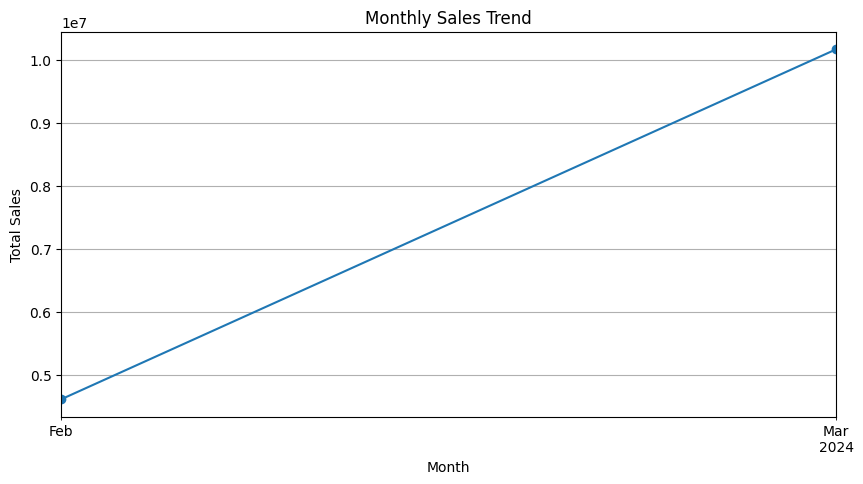

In [15]:
import matplotlib.pyplot as plt

# Group by month and sum the sales
monthly_sales = df.groupby('Month')['Order Total'].sum()

# Plotting the time series
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

**Product Analysis**

 Identify the top 10 best-selling products and analyze revenue generated by each product category.

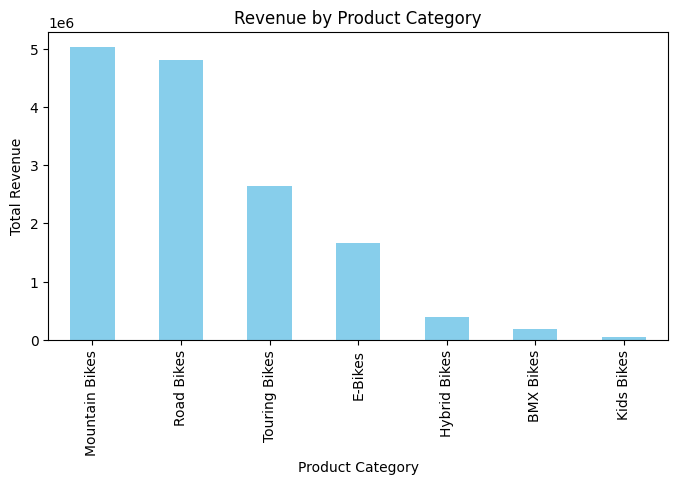

In [17]:
# Revenue by Product Category
category_revenue = df.groupby('Product Category')['Order Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
category_revenue.plot(kind='bar', color='skyblue')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.show()

**Correlation Heatmap**

We examine the correlation between numerical variables to identify how factors like price, quantity, and total sales influence each other.

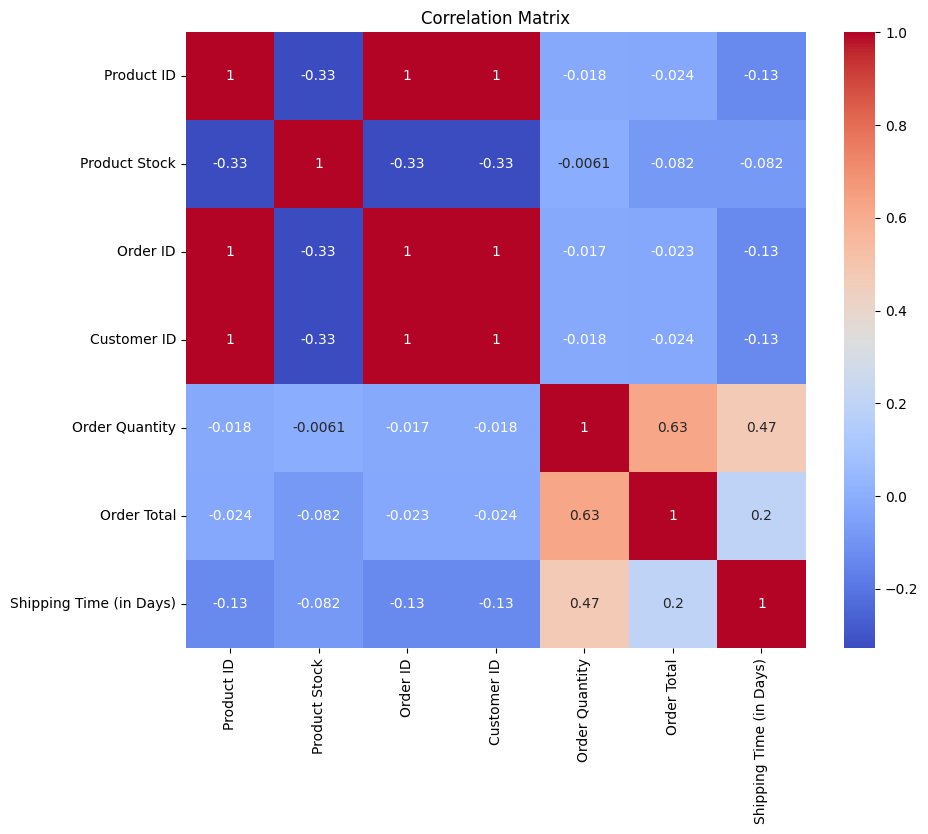

In [18]:
# Heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **Conclusion and Recommendations**

Based on the analysis of the retail sales data, here are the key insights and actionable recommendations:

**Sales Trends:** The data indicates a positive growth trend in sales from February to March 2024. This growth suggests an increasing demand or a successful marketing impact during this period.

**Top Performers:** 'Mountain Bikes' and 'Road Bikes' are the leading product categories, generating the highest revenue. These categories are the primary drivers of business performance.

**Actionable Insight:**  Given that Mountain and Road Bikes are the top performers, inventory levels for these categories should be proactively increased to prevent stockouts.

**Targeted Marketing:** Since 'Kids Bikes' and 'BMX Bikes' show lower revenue, promotional campaigns or discounts could be introduced for these categories to stimulate interest.

**Optimizing Operations:** The correlation matrix shows a positive relationship between 'Order Quantity' and 'Order Total,' confirming that larger order sizes significantly boost overall revenue. Focus on bundle deals to encourage customers to increase their order quantities.